<a href="https://colab.research.google.com/github/Matrix-69/GenAI/blob/main/GenAI_GitHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install --upgrade --force-reinstall langchain langchain-community langchain-openai faiss-cpu pdfplumber requests

  Using cached langchain-1.2.14-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_openai-1.1.12-py3-none-any.whl.metadata (3.1 kB)
  Using cached faiss_cpu-1.13.2-cp310-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.6 kB)
  Using cached pdfplumber-0.11.9-py3-none-any.whl.metadata (43 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached langchain_core-1.2.24-py3-none-any.whl.metadata (4.4 kB)
  Using cached langgraph-1.1.4-py3-none-any.whl.metadata (7.4 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached langchain_classic-1.0.3-py3-none-any.whl.metadata (4.8 kB)
  Using cached sqlalchemy-2.0.48-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Usi

In [6]:
  !pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.1 MB/s eta 0:00:00


In [7]:
    !pip install wikipedia-api


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 7.9 MB/s eta 0:00:00


    Now that the necessary libraries are installed, I'll modify the cell `V7woHB24iyVS` to include the `gensim.downloader` import, ensuring `api` is defined.
    

In [8]:
    %history -g V7woHB24iyVS
    # The previous cell output was not captured correctly, so I'm using %history to retrieve the content of cell V7woHB24iyVS to prepare for modification.
    # I will then use modify_cells to fix it in the next step.


   8:
    %history -g V7woHB24iyVS
    # The previous cell output was not captured correctly, so I'm using %history to retrieve the content of cell V7woHB24iyVS to prepare for modification.
    # I will then use modify_cells to fix it in the next step.


[==================================================] 100.0% 1662.8/1662.8MB downloaded
Most similar words:
king 0.8449392318725586
queen 0.7300517559051514
monarch 0.645466148853302
princess 0.6156251430511475
crown_prince 0.5818676352500916


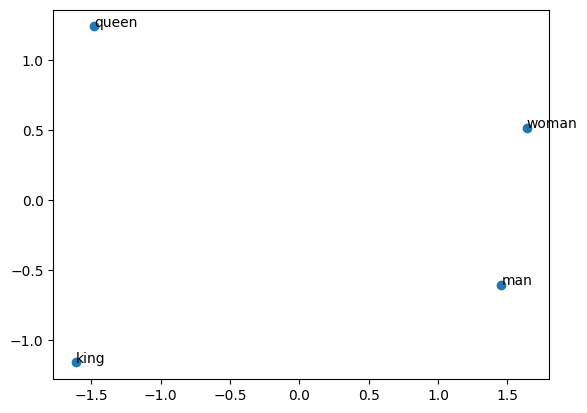

In [9]:
import gensim.downloader as api
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model = api.load('word2vec-google-news-300')

words = ['king', 'man', 'woman', 'queen']
vectors = [model[word] for word in words]

king = model['king']
man = model['man']
woman = model['woman']

result_vector = king - man + woman

similar_words = model.most_similar(result_vector, topn=5)

print("Most similar words:")
for word, sim in similar_words:
    print(word, sim)

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(words):
    plt.text(result[i, 0], result[i, 1], word)

plt.show()

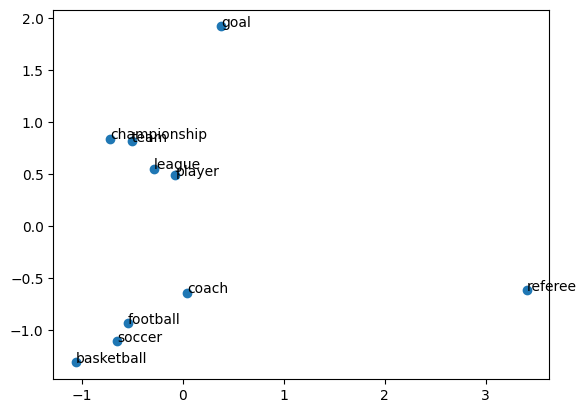

[('Soccer', 0.7622618675231934), ('football', 0.7313547730445862), ('basketball', 0.6810985207557678), ('volleyball', 0.6647275686264038), ('softball', 0.6443415284156799)]


In [10]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sports_words = ['soccer', 'football', 'basketball', 'player', 'team',
                'coach', 'referee', 'goal', 'championship', 'league']

vectors = [model[word] for word in sports_words]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(vectors)

plt.scatter(pca_result[:, 0], pca_result[:, 1])

for i, word in enumerate(sports_words):
    plt.text(pca_result[i, 0], pca_result[i, 1], word)

plt.show()

def find_similar(word):
    print(model.most_similar(word, topn=5))

find_similar('soccer')

In [12]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

corpus = [
    "The plaintiff filed a lawsuit against the defendant",
    "The court will hear the case",
    "The lawyer presented evidence",
    "The judge ruled in favor of plaintiff"
]

def preprocess(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    return [w for w in tokens if w not in stop_words and w not in string.punctuation]

processed = [preprocess(doc) for doc in corpus]

model2 = Word2Vec(processed, vector_size=100, window=5, min_count=1)

print(model2.wv.most_similar('plaintiff'))

[('court', 0.21617142856121063), ('filed', 0.0931011214852333), ('case', 0.09291722625494003), ('lawsuit', 0.07963486760854721), ('defendant', 0.06285078823566437), ('hear', 0.0270574688911438), ('lawyer', 0.016134677454829216), ('favor', -0.01083916611969471), ('evidence', -0.027750369161367416), ('ruled', -0.05234673246741295)]


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [24]:
import random
import gensim.downloader as api
word_vectors = api.load("glove-wiki-gigaword-50")

def get_similar(word):
    try:
        return [w[0] for w in word_vectors.most_similar(word, topn=3)]
    except:
        return []

def enrich(prompt):
    words = prompt.split()
    new_words = []
    for w in words:
        sim = get_similar(w)
        new_words.append(random.choice(sim) if sim else w)
    return " ".join(new_words)

prompt = "Write a short story about a brave warrior fighting a dragon"

print("Original:", prompt)
print("Enriched:", enrich(prompt))

Original: Write a short story about a brave warrior fighting a dragon
Enriched: Write another making tale there an heroic brave forces one beast


In [14]:
def create_story(seed):
    sim = get_similar(seed)
    if len(sim) < 5:
        return "Try another word"

    return f"In a world of {sim[0]} and {sim[1]}, {seed} led a journey full of {sim[2]} and {sim[3]} facing {sim[4]} challenges."

print(create_story("adventure"))

Try another word


In [18]:
from transformers import pipeline

sentiment = pipeline("sentiment-analysis")

texts = [
    "Amazing product!",
    "Worst service ever",
    "It was okay"
]

for t in texts:
    print(t, sentiment(t)[0])

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Amazing product! {'label': 'POSITIVE', 'score': 0.9998811483383179}
Worst service ever {'label': 'NEGATIVE', 'score': 0.9997915625572205}
It was okay {'label': 'POSITIVE', 'score': 0.9998207688331604}


In [16]:
from transformers import pipeline

sentiment = pipeline("sentiment-analysis")

texts = [
    "Amazing product!",
    "Worst service ever",
    "It was okay"
]

for t in texts:
    print(t, sentiment(t)[0])

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Amazing product! {'label': 'POSITIVE', 'score': 0.9998811483383179}
Worst service ever {'label': 'NEGATIVE', 'score': 0.9997915625572205}
It was okay {'label': 'POSITIVE', 'score': 0.9998207688331604}


In [21]:
import wikipediaapi
from pydantic import BaseModel

class Institution(BaseModel):
    name: str
    summary: str

wiki = wikipediaapi.Wikipedia(user_agent='Colab_Wikipedia_API_Example/1.0 (https://colab.research.google.com)', language='en')

name = "MIT"
page = wiki.page(name)

data = Institution(name=name, summary=page.summary[:500])

print(data.model_dump_json(indent=4))

{
    "name": "MIT",
    "summary": "The Massachusetts Institute of Technology (MIT) is a private research university in Cambridge, Massachusetts, United States. Founded in 1861 to advance \"useful knowledge\", the university has played a significant role in the development of many areas of technology and science.\nWilliam Barton Rogers founded MIT to accelerate American industrialization through scientific knowledge. Initially funded by a federal land grant, the institute adopted a German polytechnic model emphasizing laboratory inst"
}


In [22]:
!pip install langchain-text-splitters

In [2]:
from langchain_community.vectorstores import FAISS

In [5]:
!pip install -U langchain langchain-community langchain-openai langchain-text-splitters faiss-cpu pdfplumber requests

In [20]:
# =========================
# IPC CHATBOT - FINAL (FIXED PDF ERROR)
# =========================

import os
import requests
import pdfplumber

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

# 🔑 API KEY
os.environ["OPENAI_API_KEY"] = "your-openai-api-key-here"

# -------------------------
# STEP 1: DOWNLOAD PDF (FIXED)
# -------------------------
IPC_URL = "https://www.mha.gov.in/sites/default/files/IPAct_1860.pdf"
IPC_FILE = "ipc.pdf"

def download_pdf(url, filename):
    print("Downloading IPC document...")

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)

    # ✅ Check if actually PDF
    if "application/pdf" not in response.headers.get("Content-Type", ""):
        raise ValueError("Downloaded file is not a PDF. URL may be blocked or redirected.")

    with open(filename, "wb") as f:
        f.write(response.content)

    print("Download successful")

if not os.path.exists(IPC_FILE):
    download_pdf(IPC_URL, IPC_FILE)

# -------------------------
# STEP 2: EXTRACT TEXT
# -------------------------
print("Extracting text...")

print("Text length:", len(ipc_text))

# -------------------------
# STEP 3: SPLIT TEXT
# -------------------------
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

chunks = splitter.split_text(ipc_text)

# Optional optimization
# chunks = chunks[:200]

print("Chunks:", len(chunks))

# -------------------------
# STEP 4: VECTOR STORE
# -------------------------
print("Creating embeddings...")

# -------------------------
# STEP 5: QA SYSTEM
# -------------------------
llm = ChatOpenAI(model="gpt-3.5-turbo")


print("\n✅ Chatbot Ready (type 'exit')\n")

# -------------------------
# STEP 6: CHAT LOOP
# -------------------------
while True:
    query = input("Ask: ")

    if query.lower() == "exit":
        break

    try:
        print("Answer:", qa.run(query), "\n")
    except Exception as e:
        print("Error:", e)

Extracting text...
Text length: 0
Chunks: 0
Creating embeddings...

✅ Chatbot Ready (type 'exit')

Ask: ipc 43
Error: name 'qa' is not defined


KeyboardInterrupt: Interrupted by user